In [53]:
#imports
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import rtdl_revisiting_models as rtdl
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [54]:
#dataset 
df = pd.read_csv('dataset/prepared_data.csv')

In [55]:
#split dataset
#training(80%) validation(10%) testing(10%)
# separate features and target
X = df.drop(columns=["SongID", "hit", "peak_position", "weeks_on_chart", "first_week", "last_week"])
y = df["hit"]

# train-test split (80% train, 20% test) roughly 19000 train
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y, 
    test_size=0.2,
    random_state=426,

    # preserves hit / non-hit ratio to ensure train and set sets have 
    # similar class balance
    stratify= y
)

# Second split: 10% validation, 10% test roughly 2500 val and 2500 test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,      
    random_state=426,
    stratify=y_temp
)

In [56]:
#class balance
#overall model
import pandas as pd

balance_df = pd.DataFrame({
    "Train %": y_train.value_counts(normalize=True),
    "Val %": y_val.value_counts(normalize=True),
    "Test %": y_test.value_counts(normalize=True)
})

print(balance_df)

      Train %     Val %    Test %
hit                              
0    0.856988  0.856907  0.856966
1    0.143012  0.143093  0.143034


In [57]:
#baseline Logistic Regression Model
logistic_model = LogisticRegression(class_weight='balanced', max_iter=10000)
logistic_model.fit(X_train, y_train)
y_pred = logistic_model.predict(X_test)

In [58]:
#metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

y_proba = logistic_model.predict_proba(X_test)[:,1]
auc_score = roc_auc_score(y_test, y_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", auc_score)

Accuracy: 0.6329061595700702
Precision: 0.21770833333333334
Recall: 0.6040462427745664
F1: 0.32006125574272587
ROC-AUC: 0.6581899400215823


In [59]:
#baseline XGBoost Model
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg/pos

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [60]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", auc_score)

Accuracy: 0.7428689541132699
Precision: 0.2730263157894737
Recall: 0.4797687861271676
F1: 0.3480083857442348
ROC-AUC: 0.6983219427319041


In [61]:
#baseline MLP model 
#preprocessing 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)
X_test_scaled = scaler.fit_transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

#mlp model 
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64,1)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
model = MLP(input_dim)

In [62]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

pos_weight = torch.tensor([neg / pos], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [63]:
epochs = 100
patience = 10

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    
    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb).squeeze()
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model(xb).squeeze()
            loss = criterion(outputs, yb)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
    
    #early stop    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print("Early stopping triggered.")
        break


model.load_state_dict(best_model_state)

Epoch 1: Train Loss = 1.1323, Val Loss = 1.0900
Epoch 2: Train Loss = 1.0937, Val Loss = 1.0753
Epoch 3: Train Loss = 1.0765, Val Loss = 1.0779
Epoch 4: Train Loss = 1.0655, Val Loss = 1.0667
Epoch 5: Train Loss = 1.0598, Val Loss = 1.0662
Epoch 6: Train Loss = 1.0576, Val Loss = 1.0761
Epoch 7: Train Loss = 1.0427, Val Loss = 1.0659
Epoch 8: Train Loss = 1.0407, Val Loss = 1.0632
Epoch 9: Train Loss = 1.0366, Val Loss = 1.0702
Epoch 10: Train Loss = 1.0313, Val Loss = 1.0691
Epoch 11: Train Loss = 1.0273, Val Loss = 1.0688
Epoch 12: Train Loss = 1.0257, Val Loss = 1.0757
Epoch 13: Train Loss = 1.0184, Val Loss = 1.0669
Epoch 14: Train Loss = 1.0186, Val Loss = 1.0842
Epoch 15: Train Loss = 1.0122, Val Loss = 1.0732
Epoch 16: Train Loss = 1.0026, Val Loss = 1.0722
Epoch 17: Train Loss = 1.0057, Val Loss = 1.0773
Epoch 18: Train Loss = 0.9953, Val Loss = 1.0716
Early stopping triggered.


<All keys matched successfully>

In [64]:
#architecture
model.eval()

MLP(
  (model): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [65]:
#metrics 
with torch.no_grad():
    logits = model(X_test_tensor).squeeze()
    probs = torch.sigmoid(logits)

    y_proba = probs.numpy()
    y_pred = (y_proba > 0.5).astype(int)

auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)

print("F1:", f1)
print("ROC-AUC:", auc_score)

F1: 0.34448979591836737
ROC-AUC: 0.6983219427319041


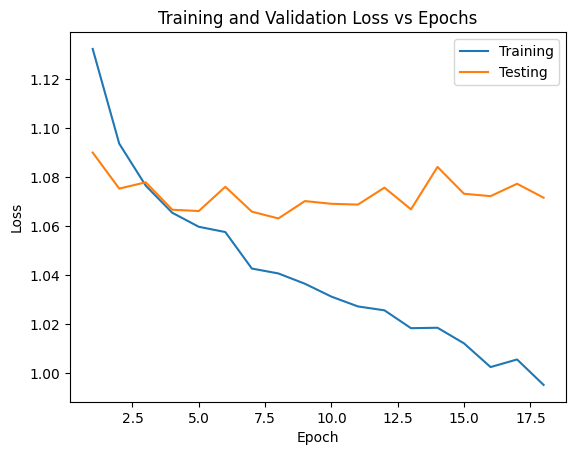

In [66]:
#loss vs epochs graph
plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses, label="Training")
plt.plot(range(1, len(val_losses)+1), val_losses, label="Testing")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Epochs")
plt.legend()
plt.show()

In [67]:
#Advanced Model (FT-Transformer)
n_features = X_train.shape[1]

kwargs = rtdl.FTTransformer.get_default_kwargs()
print(kwargs)

model = rtdl.FTTransformer(
    n_cont_features=n_features,
    cat_cardinalities=None,
    d_out=1,
    **kwargs
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

epochs = 100
patience = 10
best_val_loss = float("inf")
patience_counter = 0
train_losses = []
val_losses = []

for epoch in range(epochs):
    
    # Training
    model.train()
    train_loss = 0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()
        logits = model(xb, x_cat=None)
        loss = criterion(logits.squeeze(), yb)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb, x_cat=None)
            loss = criterion(logits.squeeze(), yb)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print("Early stopping triggered")
        break

model.load_state_dict(best_model_state)

{'n_blocks': 3, 'd_block': 192, 'attention_n_heads': 8, 'attention_dropout': 0.2, 'ffn_d_hidden': None, 'ffn_d_hidden_multiplier': 1.3333333333333333, 'ffn_dropout': 0.1, 'residual_dropout': 0.0, '_is_default': True}
Epoch 1: Train=1.1476, Val=1.1217
Epoch 2: Train=1.1083, Val=1.1275
Epoch 3: Train=1.1020, Val=1.0999
Epoch 4: Train=1.0991, Val=1.0950
Epoch 5: Train=1.0948, Val=1.1013
Epoch 6: Train=1.0958, Val=1.1006
Epoch 7: Train=1.0855, Val=1.1115
Epoch 8: Train=1.0895, Val=1.0996
Epoch 9: Train=1.0879, Val=1.1017
Epoch 10: Train=1.0800, Val=1.1260
Epoch 11: Train=1.0860, Val=1.1079
Epoch 12: Train=1.0854, Val=1.0981
Epoch 13: Train=1.0867, Val=1.1205
Epoch 14: Train=1.0801, Val=1.1472
Early stopping triggered


<All keys matched successfully>

In [68]:
#architecture
model.eval()

FTTransformer(
  (cls_embedding): _CLSEmbedding()
  (cont_embeddings): LinearEmbeddings()
  (backbone): FTTransformerBackbone(
    (blocks): ModuleList(
      (0): ModuleDict(
        (attention): MultiheadAttention(
          (W_q): Linear(in_features=192, out_features=192, bias=True)
          (W_k): Linear(in_features=192, out_features=192, bias=True)
          (W_v): Linear(in_features=192, out_features=192, bias=True)
          (W_out): Linear(in_features=192, out_features=192, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
        )
        (attention_residual_dropout): Dropout(p=0.0, inplace=False)
        (ffn_normalization): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (ffn): Sequential(
          (linear1): Linear(in_features=192, out_features=512, bias=True)
          (activation): _ReGLU()
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=192, bias=True)
        )
        (ffn_residua

In [69]:
#metrics 
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:   
        xb = xb.to(device)
        
        logits = model(xb, x_cat=None).squeeze()
        probs = torch.sigmoid(logits) 
        
        preds = (probs > 0.5).float()  
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())

f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_preds)

print('F1: ', f1)
print('ROC-AUC Score: ', auc)

F1:  0.3132530120481928
ROC-AUC Score:  0.6005753857050042


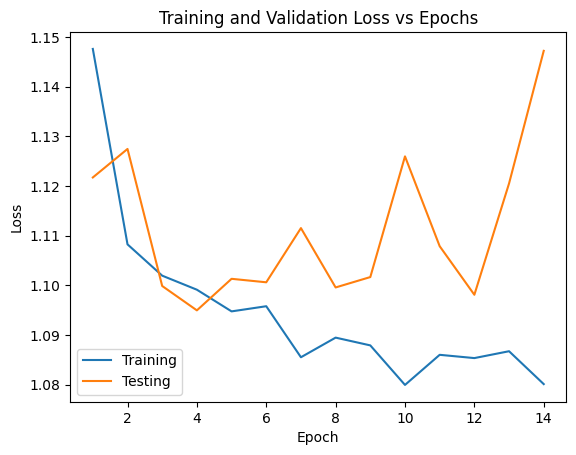

In [70]:
#loss vs epochs graph
plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses, label="Training")
plt.plot(range(1, len(val_losses)+1), val_losses, label="Testing")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Epochs")
plt.legend()
plt.show()